# task 04 of internship 

Dataset Shape: (569, 30)

Target Classes:
0 = malignant
1 = benign

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fr

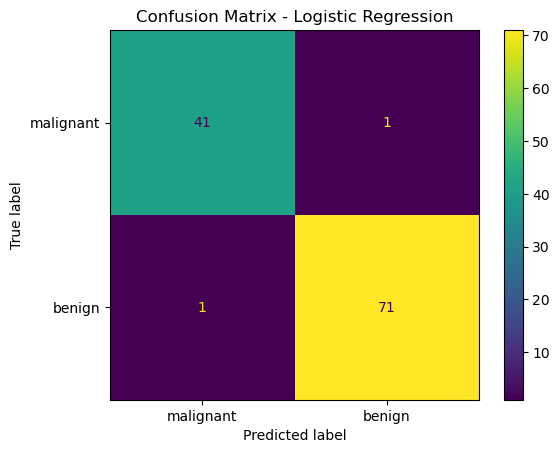


===== MODEL METRICS =====
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861


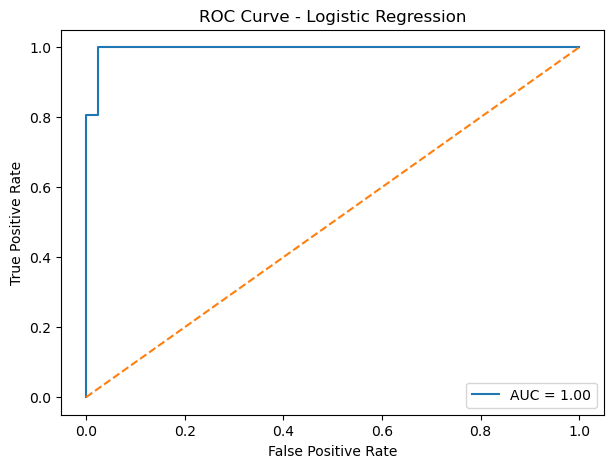

ROC-AUC Score: 0.9954

===== BALANCED LOGISTIC REGRESSION =====
Accuracy: 0.9561
Precision: 0.9855
Recall: 0.9444
F1 Score: 0.9645

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


===== DECISION TREE =====
Accuracy: 0.9123
Precision: 0.9559
Recall: 0.9028
F1 Score: 0.9286

Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


===== MODEL COMPARISON =====
                          Model  Accuracy  

In [2]:

# ============================================================
# TASK 4: CLASSIFICATION MODEL EVALUATION
# Breast Cancer Classification
# ============================================================

# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# ============================================================
# STEP 2: Load Dataset
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print("0 =", data.target_names[0])
print("1 =", data.target_names[1])

print("\nFirst 5 rows:")
print(X.head())

print("\nClass Distribution:")
print(y.value_counts())

# ============================================================
# STEP 3: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# STEP 4: Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

# ============================================================
# STEP 5: Baseline Logistic Regression
# ============================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

# ============================================================
# STEP 6: Confusion Matrix + Classification Report
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ============================================================
# STEP 7: Precision, Recall and F1 Score
# ============================================================

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== MODEL METRICS =====")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

# ============================================================
# STEP 8: ROC Curve + AUC
# ============================================================

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

# ============================================================
# STEP 9: Handle Class Imbalance
# ============================================================

balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(X_train_scaled, y_train)

y_pred_balanced = balanced_model.predict(X_test_scaled)

print("\n===== BALANCED LOGISTIC REGRESSION =====")

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_balanced), 4))

print("Precision:",
      round(precision_score(y_test, y_pred_balanced), 4))

print("Recall:",
      round(recall_score(y_test, y_pred_balanced), 4))

print("F1 Score:",
      round(f1_score(y_test, y_pred_balanced), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=data.target_names
))

# ============================================================
# STEP 10: Decision Tree Classifier
# ============================================================

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("\n===== DECISION TREE =====")

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_tree), 4))

print("Precision:",
      round(precision_score(y_test, y_pred_tree), 4))

print("Recall:",
      round(recall_score(y_test, y_pred_tree), 4))

print("F1 Score:",
      round(f1_score(y_test, y_pred_tree), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=data.target_names
))

# ============================================================
# STEP 11: Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_tree)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_tree)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_tree)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_tree)
    ]
})

print("\n===== MODEL COMPARISON =====")
print(comparison.round(4))

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n====================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("====================================")

print("\nDataset:", "Breast Cancer Wisconsin Dataset")
print("Problem Type:", "Binary Classification")
print("Models Used:")
print("1. Logistic Regression")
print("2. Balanced Logistic Regression")
print("3. Decision Tree")

print("\nEvaluation Metrics:")
print("Accuracy")
print("Precision")
print("Recall")
print("F1 Score")
print("ROC-AUC")

print("\nROC-AUC:", round(auc_score, 4))